## Numerical

Goal : ดูการกระจายตัว (Distribution) ว่าเบ้ (Skewed) ไหม? มี Outliers ที่ต้องจัดการไหม?

### Checking Distribution

In [7]:
import math
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from IPython.display import display


In [8]:
import pandas as pd
from pathlib import Path

# --- Configuration ---
USE_SAMPLE = True
# สมมติว่า Notebook อยู่ในโฟลเดอร์ notebooks/eda/
DATA_DIR = Path('../../data/processed/quality') 

def load_data(table_name, sample=True):
    suffix = '_sample' if sample else ''
    file_path = DATA_DIR / f"{table_name}_clean{suffix}.csv"
    print(f"Loading: {file_path.name}")
    return pd.read_csv(file_path)

# 1. Load Data
try:
    orders = load_data('orders', USE_SAMPLE)
    order_products = load_data('order_products_prior', USE_SAMPLE)
except FileNotFoundError as e:
    print(f"Error: ไม่พบไฟล์ข้อมูลที่ {DATA_DIR}. กรุณาเช็ก Path อีกครั้ง")
    raise e

# 2. Integrity Check (สำคัญมาก!)
match_rate = order_products['order_id'].isin(orders['order_id']).mean()
if match_rate < 1.0:
    print(f"⚠️ Warning: ข้อมูลไม่ Match กันอยู่ { (1-match_rate)*100 :.2f}%")

# 3. Merge เพื่อเตรียมทำ Behavioral EDA
df = order_products.merge(orders, on='order_id', how='left')

print(f"--- Summary ({'Sample' if USE_SAMPLE else 'Full'}) ---")
print(f"Rows: {len(df):,}")
print(f"Missing after join:\n{df.isnull().sum()}")
df.head()

Loading: orders_clean_sample.csv
Loading: order_products_prior_clean_sample.csv
--- Summary (Sample) ---
Rows: 9,356
Missing after join:
order_id                  0
product_id                0
add_to_cart_order         0
reordered                 0
user_id                   0
eval_set                  0
order_number              0
order_dow                 0
order_hour_of_day         0
days_since_prior_order    0
dtype: int64


,order_id,product_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,322,13819,1,1,36278,prior,2,1,9,7.0
1,322,432,2,1,36278,prior,2,1,9,7.0
2,322,19311,3,1,36278,prior,2,1,9,7.0
3,322,36646,4,0,36278,prior,2,1,9,7.0
4,322,28842,5,1,36278,prior,2,1,9,7.0


In [9]:
palette_level = {
    'Strong': '#c8553d',
    'Moderate': '#4c956c',
    'Weak': '#577590',
    'None': '#b7b7a4'
}
churn_palette = {0: '#4c78a8', 1: '#e45756'}
level_order = ['Strong', 'Moderate', 'Weak', 'None']

sns.set_theme(style="whitegrid")

<Figure size 700x400 with 0 Axes>

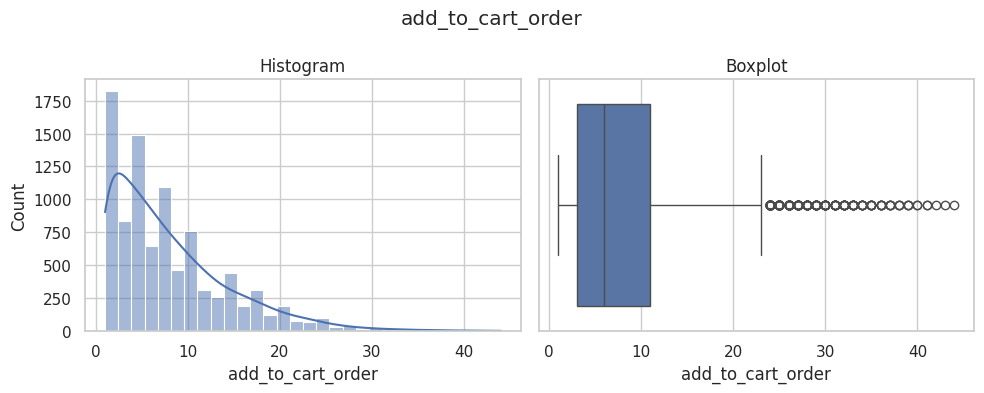

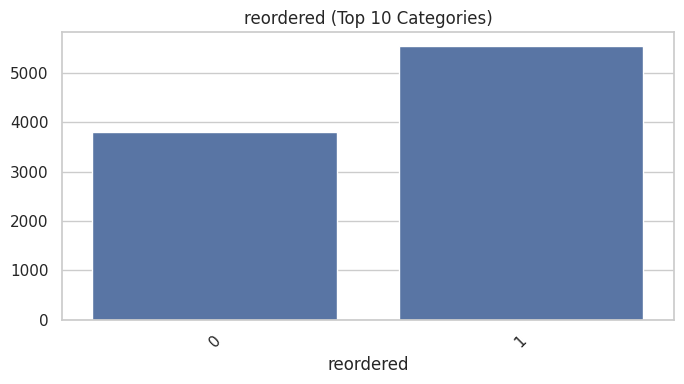

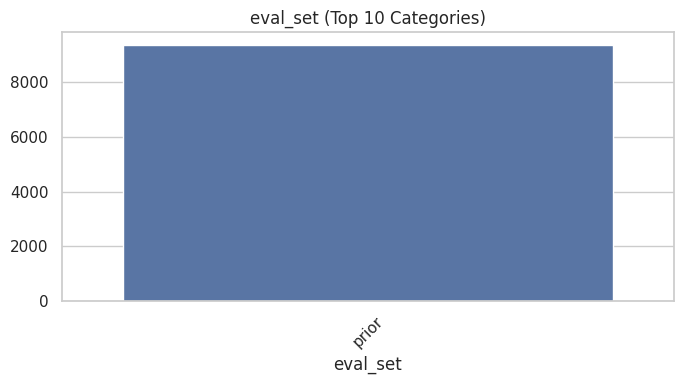

<Figure size 700x400 with 0 Axes>

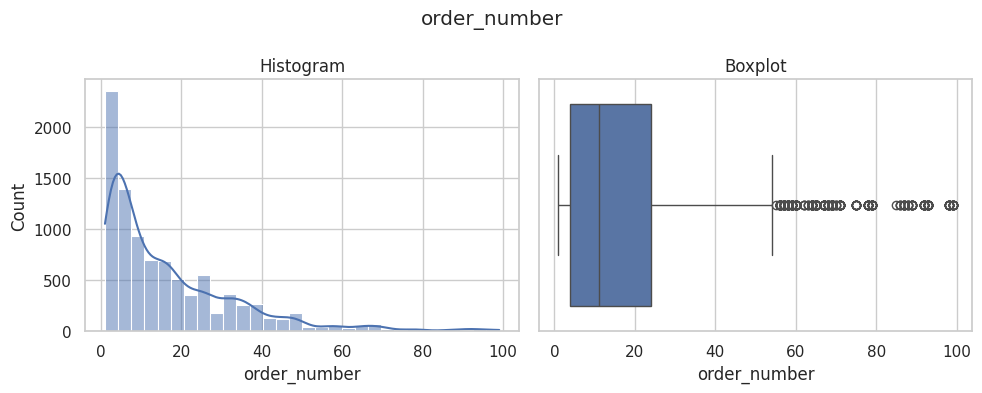

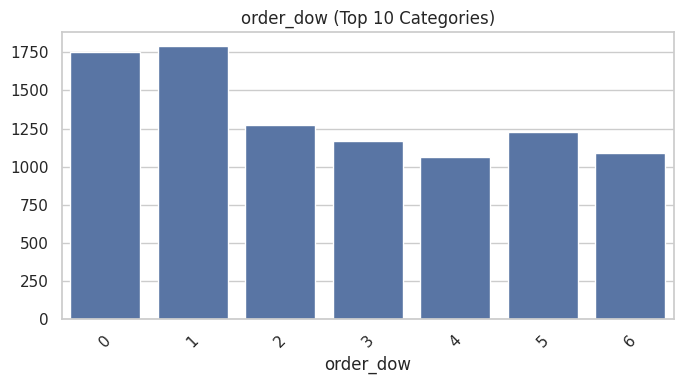

<Figure size 700x400 with 0 Axes>

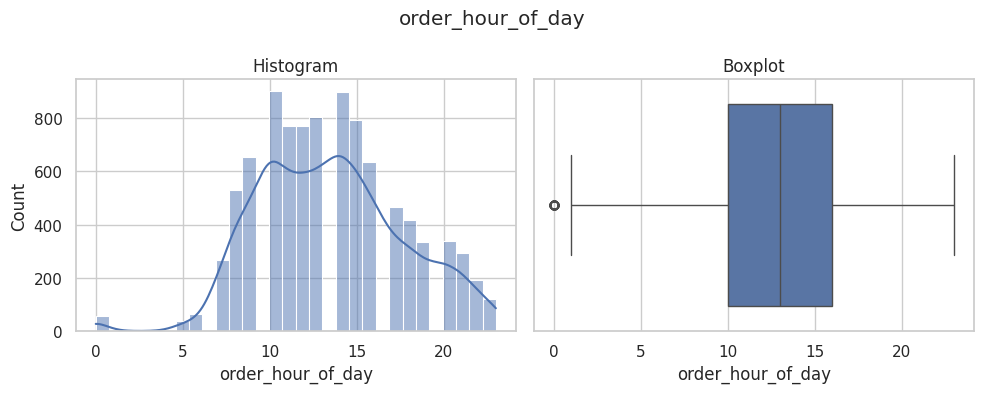

<Figure size 700x400 with 0 Axes>

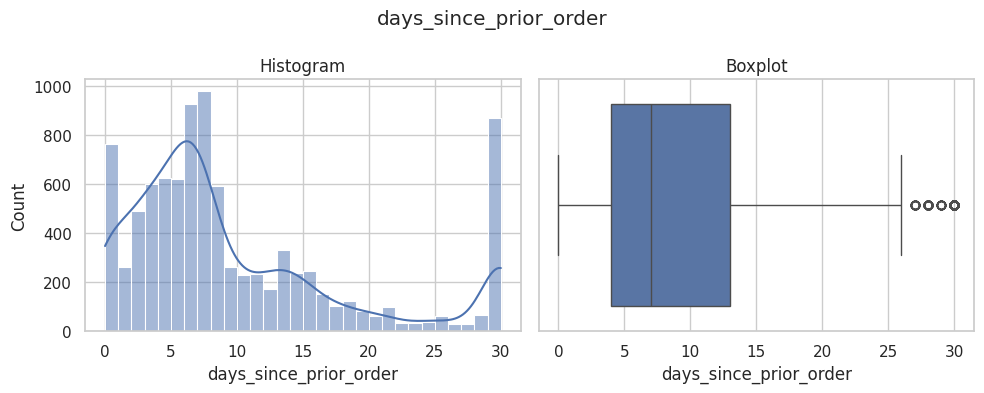

In [13]:
for col in df.columns:
    
    # ❌ ตัด id ออก
    if "id" in col.lower():
        continue

    unique_vals = df[col].nunique()
    plt.figure(figsize=(7, 4))

    # 🟢 CATEGORICAL
    if df[col].dtype == "object" or unique_vals < 10:
        
        # 👉 เอา top 10
        top_vals = df[col].value_counts().nlargest(10)
        
        sns.barplot(x=top_vals.index, y=top_vals.values)
        plt.xticks(rotation=45)
        plt.title(f"{col} (Top 10 Categories)")

    # 🔵 NUMERIC
    elif df[col].dtype in ["int64", "float64"]:
        
        # 🟡 BINARY
        if unique_vals <= 2:
            sns.countplot(x=col, data=df)
            plt.title(f"{col} (Binary)")

        # 🟠 DISCRETE
        elif unique_vals < 20:
            sns.histplot(df[col], bins=min(unique_vals, 15))
            plt.title(f"{col} (Discrete)")

        # 🔴 CONTINUOUS
        else:
            fig, axes = plt.subplots(1, 2, figsize=(10, 4))
            
            sns.histplot(df[col], kde=True, bins=30, ax=axes[0])
            axes[0].set_title("Histogram")

            sns.boxplot(x=df[col], ax=axes[1])
            axes[1].set_title("Boxplot")

            fig.suptitle(col)
            plt.tight_layout()
            plt.show()
            continue

    else:
        plt.close()
        continue

    plt.tight_layout()
    plt.show()